# Notebook 06: Calibration (SQ2)

Adds sample-size-scaled bin counts, bootstrap bias-corrected ECE, a Kermany-624 -> n=30 size-matched subsampling sanity check, and run-level (per architecture) ECE CIs, replacing the pooled-row ECE bootstrap.

## 1. Setup

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

import sys
from pathlib import Path

REPO_ON_DRIVE = "/content/drive/MyDrive/MSc AI DISSERTATION/crosspop-cxr-asymmetry"
for candidate in [REPO_ON_DRIVE, "..", "."]:
    p = Path(candidate).resolve()
    if (p / "config.py").exists():
        sys.path.insert(0, str(p))
        break

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from src import metrics as MET
from src import stats as ST
from src import results as RES

for mod in (config, MET, ST, RES):
    importlib.reload(mod)

config.ensure_output_dirs()
config.set_plot_style()


Mounted at /content/drive


In [2]:
ext_summary = pd.read_csv(config.RESULTS_DIR / "04_inference_summary_extended.csv")
meta, arrays = RES.load_predictions(config.RESULTS_DIR / "predictions")
print(f"Loaded {len(meta)} prediction files; extended summary {ext_summary.shape}")


Loaded 114 prediction files; extended summary (114, 16)


## 2. Debiased ECE per run

Recomputed directly from raw predictions (not the temperature-scaled versions used elsewhere), isolating the small-n bias question from the separate temperature-scaling question addressed in the original notebook 06.

In [3]:
debiased_rows = []
for row_key, entry in arrays.items():
    matching_meta = meta[meta["stem_full"] == row_key]
    if len(matching_meta) == 0:
        continue
    info = matching_meta.iloc[0].to_dict()
    y_true = entry["y_true"]
    y_prob = entry["y_prob"]
    n = len(y_true)
    n_bins = MET.n_bins_for_sample_size(n, config.ECE_MIN_BINS, config.ECE_MAX_BINS)
    debiased_ece, raw_ece, bias = MET.bootstrap_debiased_ece(
        y_true, y_prob, n_bins=n_bins, n_boot=config.DEBIAS_ECE_N_BOOT, seed=config.SEED
    )
    debiased_rows.append({
        "arch": info.get("arch"), "direction": info.get("direction"),
        "condition": info.get("condition"), "size": info.get("size"),
        "seed": info.get("seed"), "fold": info.get("fold"),
        "n": n, "n_bins_used": n_bins,
        "ece_raw_fixed15": MET.expected_calibration_error(y_true, y_prob, 15),
        "ece_raw_sqrtn": raw_ece, "ece_debiased": debiased_ece, "estimated_bias": bias,
    })

debiased_df = pd.DataFrame(debiased_rows)
print("\n--- Debiased ECE, first 10 rows ---")
print(debiased_df.head(10).to_string(index=False))
debiased_df.to_csv(config.RESULTS_DIR / "06_debiased_ece.csv", index=False)



--- Debiased ECE, first 10 rows ---
           arch direction condition  size  seed  fold   n  n_bins_used  ece_raw_fixed15  ece_raw_sqrtn  ece_debiased  estimated_bias
efficientnet_b0       K2N       K2K   100    42   NaN 624           15         0.043990       0.043990      0.031365        0.012625
efficientnet_b0       K2N  K2N_full   100    42   NaN 190           14         0.208540       0.200864      0.183030        0.017834
efficientnet_b0       K2N       K2N   100    42   NaN  30            5         0.364981       0.325630      0.300015        0.025615
efficientnet_b0       K2N       K2K   100    43   NaN 624           15         0.067427       0.067427      0.063468        0.003959
efficientnet_b0       K2N  K2N_full   100    43   NaN 190           14         0.302539       0.286567      0.269919        0.016648
efficientnet_b0       K2N       K2N   100    43   NaN  30            5         0.381695       0.341864      0.338635        0.003229
efficientnet_b0       K2N       

## 3. Kermany-624 -> n=30 size-matched subsampling sanity check (per architecture)

Repeatedly subsample each architecture's N2K Kermany-test predictions down to 30 images and recompute ECE, to see how much of the K2N-vs-N2K calibration gap survives once evaluation-set size is matched between directions.


--- Size-matched subsampling check, per architecture (target n=30, bins=5) ---

mobilenet_v2:
  N2K (Kermany-624) subsampled to n=30, 500 repeats:
    Mean ECE: 0.220  [0.092, 0.370]
  K2N actual (pooled Togunwa holdout, n=30 x n_seeds): 0.272
  K2N ECE does NOT clearly exceed the N2K size-matched subsampling distribution for mobilenet_v2 -- part of the gap may be a small-n artifact for this architecture.

efficientnet_b0:
  N2K (Kermany-624) subsampled to n=30, 500 repeats:
    Mean ECE: 0.184  [0.072, 0.320]
  K2N actual (pooled Togunwa holdout, n=30 x n_seeds): 0.224
  K2N ECE does NOT clearly exceed the N2K size-matched subsampling distribution for efficientnet_b0 -- part of the gap may be a small-n artifact for this architecture.


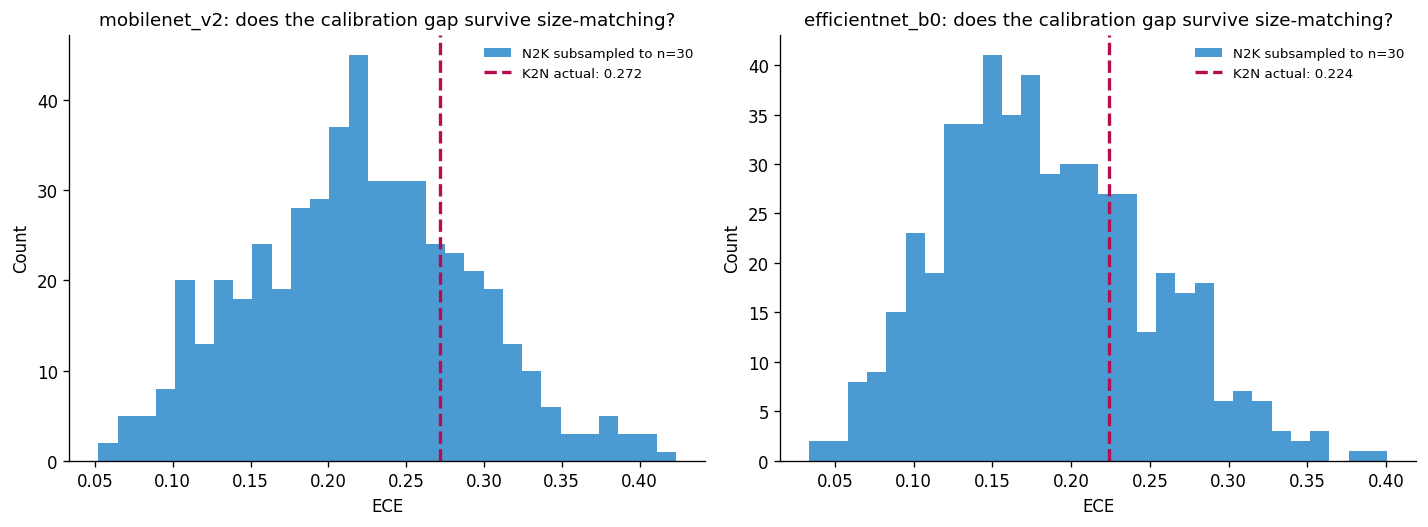


--- Subsampling check summary, per architecture ---
           arch  n2k_subsampled_mean_ece  n2k_subsampled_lo  n2k_subsampled_hi  k2n_actual_ece  gap_survives_size_matching
   mobilenet_v2                    0.220              0.092               0.37           0.272                       False
efficientnet_b0                    0.184              0.072               0.32           0.224                       False


In [4]:
def subsample_ece_distribution(y_true, y_prob, target_n, n_repeats, n_bins, seed):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    eces = np.empty(n_repeats)
    for i in range(n_repeats):
        idx = rng.choice(n, size=min(target_n, n), replace=False)
        eces[i] = MET.expected_calibration_error(y_true[idx], y_prob[idx], n_bins)
    return eces

match_bins = MET.n_bins_for_sample_size(config.TOGUNWA_HOLDOUT_SIZE, config.ECE_MIN_BINS, config.ECE_MAX_BINS)

print(f"\n--- Size-matched subsampling check, per architecture (target n={config.TOGUNWA_HOLDOUT_SIZE}, bins={match_bins}) ---")

subsample_rows = []

fig, axes = plt.subplots(1, len(config.ARCHITECTURES), figsize=(6 * len(config.ARCHITECTURES), 4.5), squeeze=False)

for i, arch in enumerate(config.ARCHITECTURES):
    n2k_true, n2k_prob = RES.pool_predictions(meta, arrays, condition="N2K", arch=arch)
    k2n_true, k2n_prob = RES.pool_predictions(meta, arrays, condition="K2N", arch=arch)

    subsample_eces = subsample_ece_distribution(
        n2k_true, n2k_prob,
        target_n=config.TOGUNWA_HOLDOUT_SIZE,
        n_repeats=config.SUBSAMPLE_N_REPEATS,
        n_bins=match_bins,
        seed=config.SEED,
    )
    k2n_ece_actual = MET.expected_calibration_error(k2n_true, k2n_prob, match_bins)

    sub_lo, sub_hi = np.percentile(subsample_eces, [2.5, 97.5])
    gap_survives = k2n_ece_actual > np.percentile(subsample_eces, 97.5)

    print(f"\n{arch}:")
    print(f"  N2K (Kermany-624) subsampled to n={config.TOGUNWA_HOLDOUT_SIZE}, {config.SUBSAMPLE_N_REPEATS} repeats:")
    print(f"    Mean ECE: {subsample_eces.mean():.3f}  [{sub_lo:.3f}, {sub_hi:.3f}]")
    print(f"  K2N actual (pooled Togunwa holdout, n={config.TOGUNWA_HOLDOUT_SIZE} x n_seeds): {k2n_ece_actual:.3f}")
    print(f"  K2N ECE {'exceeds' if gap_survives else 'does NOT clearly exceed'} the N2K size-matched "
          f"subsampling distribution for {arch} -- "
          f"{'the gap likely survives size-matching' if gap_survives else 'part of the gap may be a small-n artifact'} "
          f"for this architecture.")

    subsample_rows.append({
        "arch": arch,
        "n2k_subsampled_mean_ece": round(float(subsample_eces.mean()), 3),
        "n2k_subsampled_lo": round(float(sub_lo), 3), "n2k_subsampled_hi": round(float(sub_hi), 3),
        "k2n_actual_ece": round(float(k2n_ece_actual), 3),
        "gap_survives_size_matching": bool(gap_survives),
    })

    ax = axes[0, i]
    ax.hist(subsample_eces, bins=30, alpha=0.7, color=config.BRAND["C3"], label="N2K subsampled to n=30")
    ax.axvline(k2n_ece_actual, color=config.BRAND["C1"], linestyle="--", linewidth=2,
               label=f"K2N actual: {k2n_ece_actual:.3f}")
    ax.set_xlabel("ECE")
    ax.set_ylabel("Count")
    ax.set_title(f"{arch}: does the calibration gap survive size-matching?")
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "06_subsampling_check.png", dpi=120, bbox_inches="tight")
plt.show()

subsample_summary = pd.DataFrame(subsample_rows)
print("\n--- Subsampling check summary, per architecture ---")
print(subsample_summary.to_string(index=False))
subsample_summary.to_csv(config.RESULTS_DIR / "06_subsampling_check.csv", index=False)


## 4. Run-level debiased ECE CIs, per condition and architecture (PRIMARY)

In [5]:
print("\n--- Run-level debiased ECE CIs by condition and architecture ---")
ece_rows = []
for (cond, arch), grp in debiased_df.groupby(["condition", "arch"]):
    vals = grp["ece_debiased"].dropna().values
    if len(vals) < 2:
        continue
    mean_est, lo, hi, _ = ST.run_level_bootstrap_ci(vals, seed=config.SEED)
    ece_rows.append({
        "condition": cond, "arch": arch, "n_runs": len(vals),
        "ece_debiased_mean": round(mean_est, 3), "ece_lo": round(lo, 3), "ece_hi": round(hi, 3)
    })

ece_table = pd.DataFrame(ece_rows).sort_values(["arch", "condition"])
print(ece_table.to_string(index=False))
ece_table.to_csv(config.RESULTS_DIR / "06_run_level_ece.csv", index=False)



--- Run-level debiased ECE CIs by condition and architecture ---
condition            arch  n_runs  ece_debiased_mean  ece_lo  ece_hi
      K2K efficientnet_b0       9              0.056   0.034   0.089
      K2N efficientnet_b0       9              0.227   0.166   0.281
 K2N_full efficientnet_b0       9              0.206   0.175   0.236
      N2K efficientnet_b0      15              0.151   0.124   0.178
      N2N efficientnet_b0      15              0.061   0.029   0.101
      K2K    mobilenet_v2       9              0.090   0.074   0.108
      K2N    mobilenet_v2       9              0.270   0.227   0.314
 K2N_full    mobilenet_v2       9              0.267   0.227   0.302
      N2K    mobilenet_v2      15              0.183   0.132   0.229
      N2N    mobilenet_v2      15              0.082   0.040   0.126


## 5. Reliability diagrams, per architecture (descriptive only)

Pooled across runs for visualisation purposes only. The inferential claims live in the run-level tables above, not in this plot.

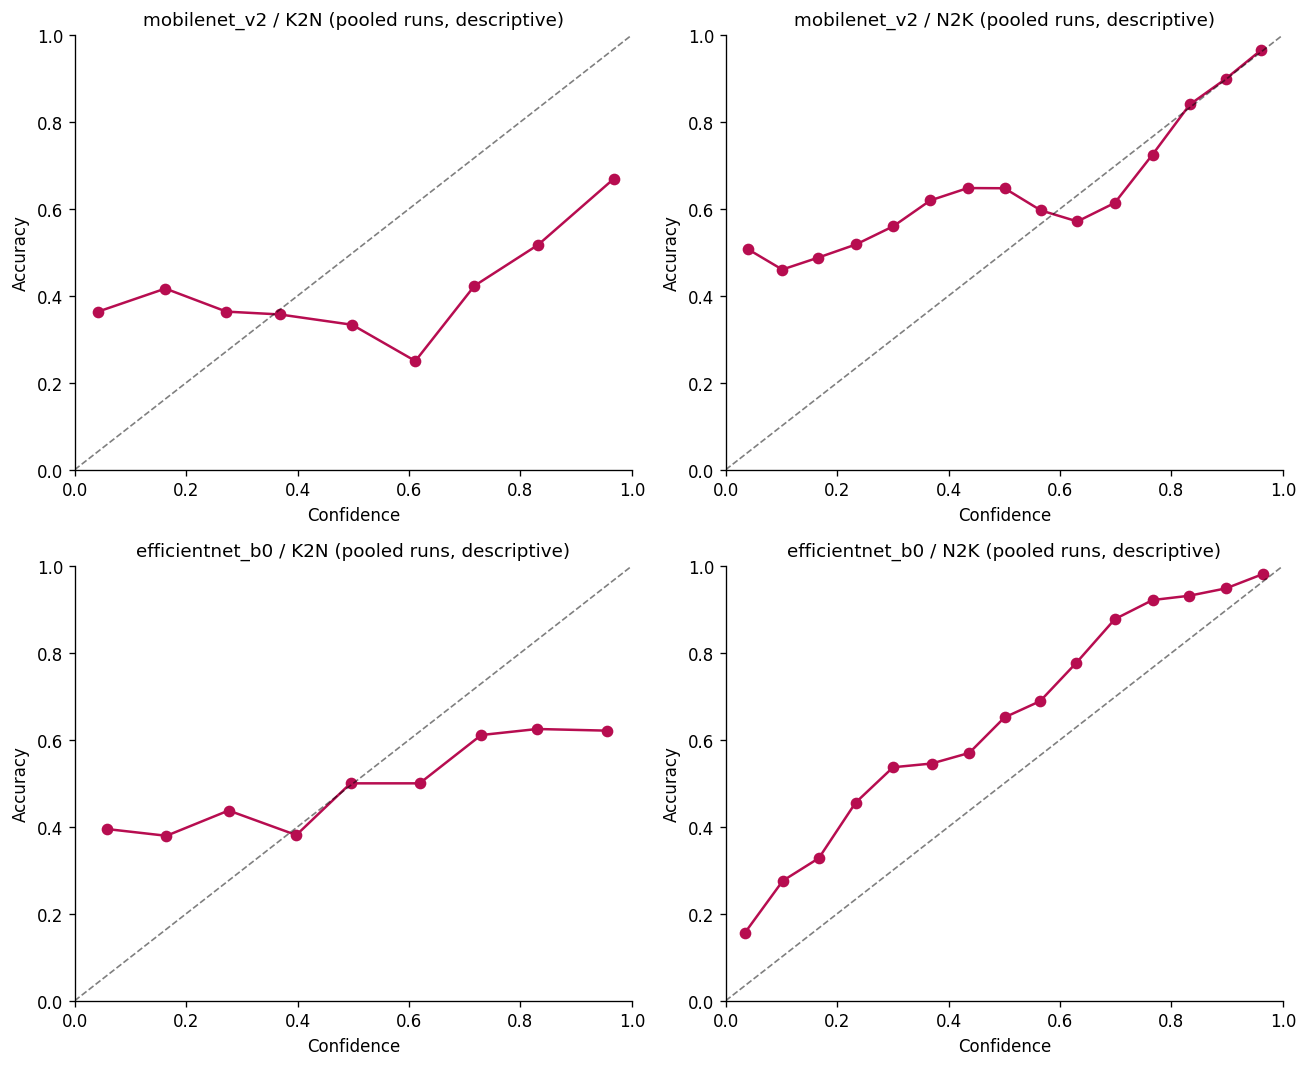

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, arch in enumerate(config.ARCHITECTURES):
    for col, condition in enumerate(["K2N", "N2K"]):
        ax = axes[row, col]
        y_true_p, y_prob_p, img_ids_p = RES.pool_predictions(
            meta, arrays, condition=condition, arch=arch, include_image_id=True
        )
        n_unique_images = len(np.unique(img_ids_p))
        n_bins_p = MET.n_bins_for_sample_size(n_unique_images, config.ECE_MIN_BINS, config.ECE_MAX_BINS)
        conf, acc = MET.reliability_curve(y_true_p, y_prob_p, n_bins=n_bins_p)
        ax.plot(conf, acc, marker="o", color=config.BRAND["C1"])
        ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
        ax.set_title(f"{arch} / {condition} (pooled runs, descriptive)")
        ax.set_xlabel("Confidence")
        ax.set_ylabel("Accuracy")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "06_reliability.png", dpi=120, bbox_inches="tight")
plt.show()


**Next:** notebook 07 (size interaction, SQ3).